## *Proposition de workflow pour le process de données µSAXS*

#### **Problématique**

Les données de cartographie µSAXS (SWING) sont généralement enregistrées en enregistrant toutes les images correspondant à une ligne du scan (une position z) dans un seul et unique fichier h5 (qui contient les images SAXS pour les différentes valeurs de x).
Ainsi, on ne peut plus considérer le fichier h5 comme étant un échantillon unique et moyenner les images qui y sont contenues.

#### **Proposition de workflow**

Le workflow proposé regroupe les étapes suivantes:
- conversion d'un fichier h5 en plusieurs images edf (avec conservation des meta-données, notamment des positions moteurs)
- utilisation du code saxsprocessor en utilisant l'ensemble des fichiers edf comme fichiers uniques
- on écrira ensuite de nouvelles fonctions pour faire les cartographies (de paramètre nématique, d'orientation, etc...)


Dans un premier temps, on décrit le workflow sur un fichier h5 unique. Dans un second temps, nous montrerons les fonctions à utiliser pour tracer la cartographie du paramètre nématique et son orientation à partir d'une série de fichiers h5 correspondant à un même assemblage.



## I/ Test sur fichier unique

Le but de ce test est de montrer comment cela fonctionne. Il y a 

#### **Etape 1: Conversion des fichiers h5 en edf**

On utilise la méthode 'convert2edf' de la classe h5File_SWING, en précisant bien qu'on ne veut PAS moyenner les images (passer l'argument mean=False lors de l'instantiation de la classe).
Remarque: Dans le parser du format edf, le binning est par défaut 1. Par conséquent, la taille des pixels est mutlipliée par les paramètres de binning pendant la conversion en format edf.

In [1]:
%matplotlib widget
from filereaders import h5File_SWING
from utilities import *

# Make pyfai warning silent (optional, but nicer output)
import logging, warnings

logging.getLogger("pyFAI").setLevel(logging.ERROR)
logging.getLogger("fabio").setLevel(logging.ERROR)

warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide",
    module="pyFAI"
)


waxsprocessor.py not found


L'étape suivante permet de convertir le fichier mask fourni par l'équipe de SWING dans un format compatible avec celui utilisé dans SAXSProcessor (convention pyFAI). 
Le masque fourni étant incomplet (manque le beamstop), on utilise un autre fichier édité avec pyFAI (via SAXS_toolbox, mais c'est une autre histoire).

In [22]:

testfile = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/lacroix_04288_2024-07-22_01-32-09.h5'
edfpath='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/'
file = h5File_SWING(testfile,mean = False) # we do not average data contained in this file, we force linescan (step_z=0)


# Convert mask from SWING mask (just to show it is possible)
mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_lacroix_jul24.txt'
mask=file.convert_SWING_mask(maskfile=mask)

# as beamstop is missing on this mask, we use the following file:
mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask.edf'

# convert h5file to edf files
file.convert2edf(outputdir=edfpath)

print(f'Scan parameters: xstart = {file.position_x_start}step x: {file.step_x}, zstart={file.position_z_start},step_z:{file.step_z}')


Mask file was successfully imported and converted in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask_pyfai.edf
Scan parameters: xstart = [94.5999]step x: [45.44545455], zstart=[20.35],step_z:0


#### **Etape 2: Traitement des fichiers individuels**

Pour l'exemple, on va ici faire un plot de l'évolution du paramètre nématique des figures de diffusion en fonction de la position du moteur x. 
On va d'abord tracer un profil radial large pour trouver une valeur de q d'intérêt pour l'extraction du profil azimuthal et on calculera ensuite le paramètre d'ordre nématique pour chaque image/position x contenue dans le fichier h5.

Text(0, 0.5, 'I(q)')

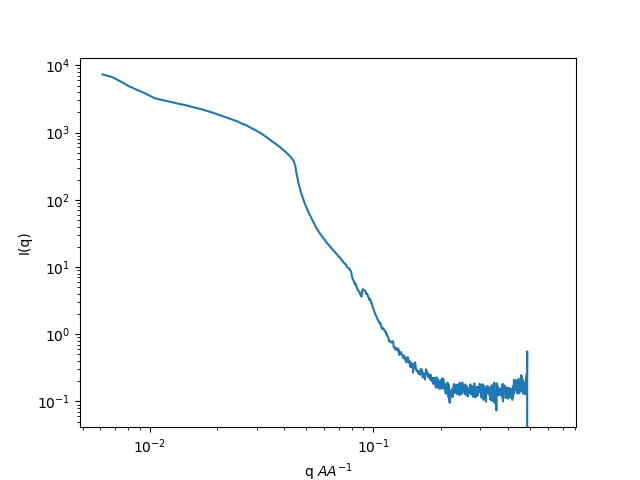

In [23]:
from saxsprocessor import SAXSProcessor
import glob
import os
import numpy as np
from matplotlib import pyplot as plt
import re

# retrieve the number of points from the h5file
number_of_images = file.nb_frames
file_filter = '*Img*.edf'  # be careful not to include the mask in this list
instrument = 'LGC'

# Establish a list of files
filelist = glob.glob(os.path.join(edfpath,file_filter))

# Sort the file list (we need to define a function)
# files are sorted by File_number.Img 

def sort_edf(file):
    match = re.search(r'File_(\d+)_Img_(\d+)', file)
    if not match:
        raise ValueError("Format de fichier non reconnu")

    return int(match.group(1)), int(match.group(2))
    
filelist = sorted(filelist, key = sort_edf)

# tracé du profil radial
file = filelist[0]
proc = SAXSProcessor(file, mask=mask, instrument='LGC') # instrument is set to 'LGC' as we are dealing with edf files now.
q,I = proc.extract_radial_profile(width=360)

plt.figure()
plt.loglog(q,I)
plt.xlabel('q $AA^{-1}$')
plt.ylabel('I(q)')


#### Determination du paramètre nématique

Ici, on va utiliser la fonction "compute_nematic_parameter" disponible dans le fichier utilities.py. 
Cette fonction prend comme arguments les paramètres de taille utiles au calcul du facteur de forme (ici on utilise les paramètres par défaut). Pour le calcul du facteur de forme, l'orientation du cylindre est déterminée à partir de l'image SAXS (= maximum d'intensité sur le profil azimuthal) 
Voici la liste des arguments de la fonction "compute_nematic_parameter":

    *** Args ***

    processor: SAXSProceesor instance
        SAXSProcessor instance (mandatory)

    qvalue: float
        q value of interest at which azimuthal profile is extracted

    threshold: float
        relative value to defin the q range for azimuthal profile extraction

    radius: float
        Cylinder radius for form factor caclulation

    L: float
        Cylinder length for form factor calculation

    radius_pd, L_pd: float
        Polydispersity ratio for radius and length

    plot : bool
        Plot form factor and fitting results

    apply_mirror: bool
        Apply mirror symmetry to incomplete exp azimuthal profile

    *** Returns ****
    results : dict
        {'I0': I0_opt,
        'm': m_opt,
        'x0': x0_opt,
        'a': a_opt,
        'b': b_opt,
        'S': S_opt,
        'R2': r_squared,
        'I_model': I_model}
    


- 1. Extraction profil azimuthal


************************************************************************************************************************

 Processing file 1 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_0.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_0.png
Main orientation is  80.32721394638307

Computing cylinder form factor...


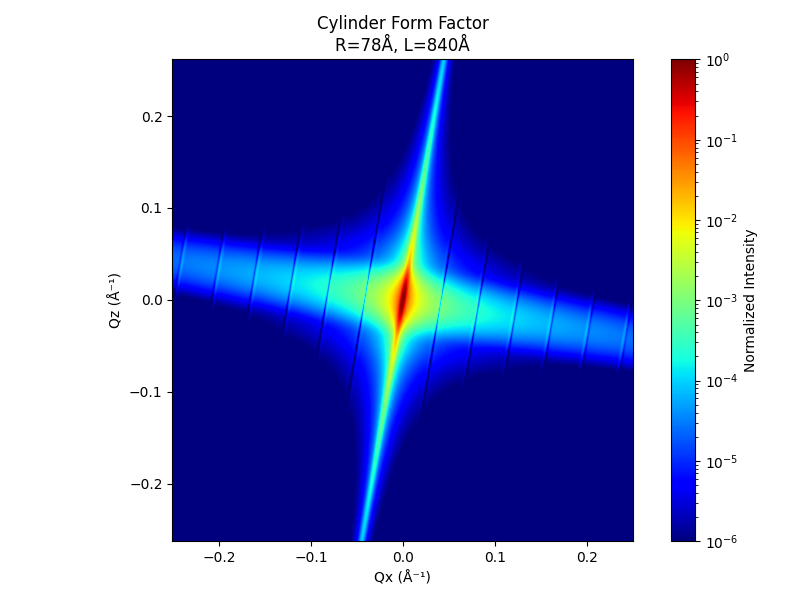


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=94.60_z=20.35_Img0_nematic_determination.png

Fitting results:
x0: 78.98082349355491
S: 0.9106326172199782
R2: 0.9339923133687016

************************************************************************************************************************

 Processing file 2 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_1.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_1.png
Main

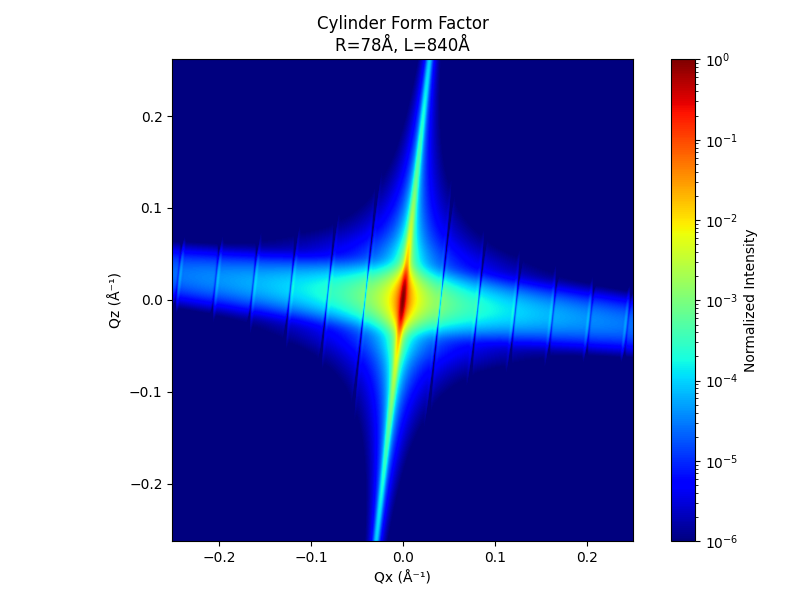


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=140.05_z=20.35_Img1_nematic_determination.png

Fitting results:
x0: 82.50118253803441
S: 0.9330340230412538
R2: 0.9192924388273133

************************************************************************************************************************

 Processing file 3 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_2.edf

************************************************************************************************************************


/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/saxsprocessor.py:352: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(dpi=200)


SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_2.png
Main orientation is  84.32648238753274

Computing cylinder form factor...


/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/nematicordercalculator.py:470: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 6))


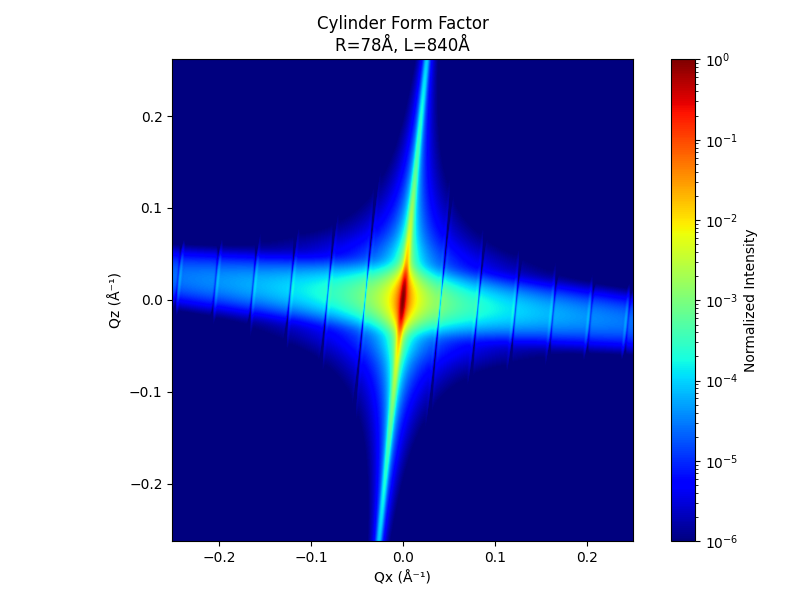


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=185.49_z=20.35_Img2_nematic_determination.png

Fitting results:
x0: 83.82348366507193
S: 0.9353943766029805
R2: 0.9147085679140594

************************************************************************************************************************

 Processing file 4 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_3.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_3.png
Mai

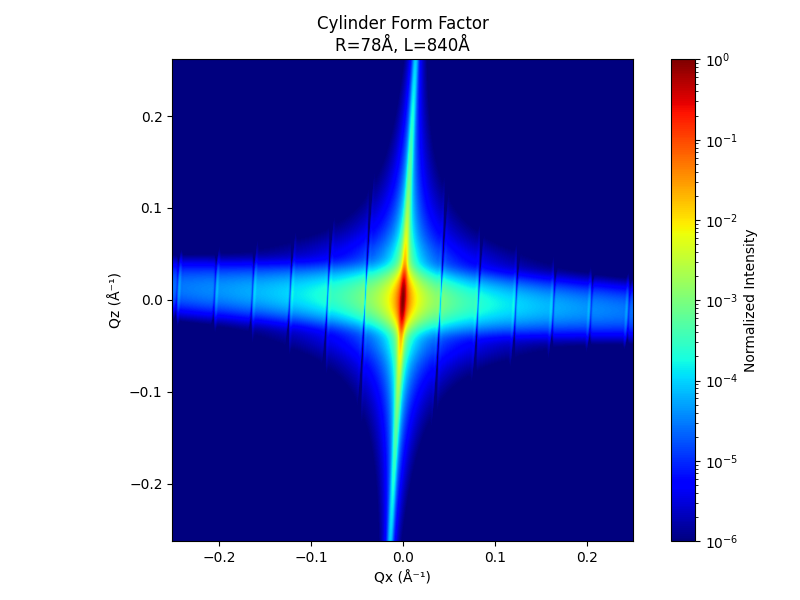


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=230.94_z=20.35_Img3_nematic_determination.png

Fitting results:
x0: 85.5406129298317
S: 0.9330253770383765
R2: 0.9121005717815294

************************************************************************************************************************

 Processing file 5 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_4.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_4.png
Main

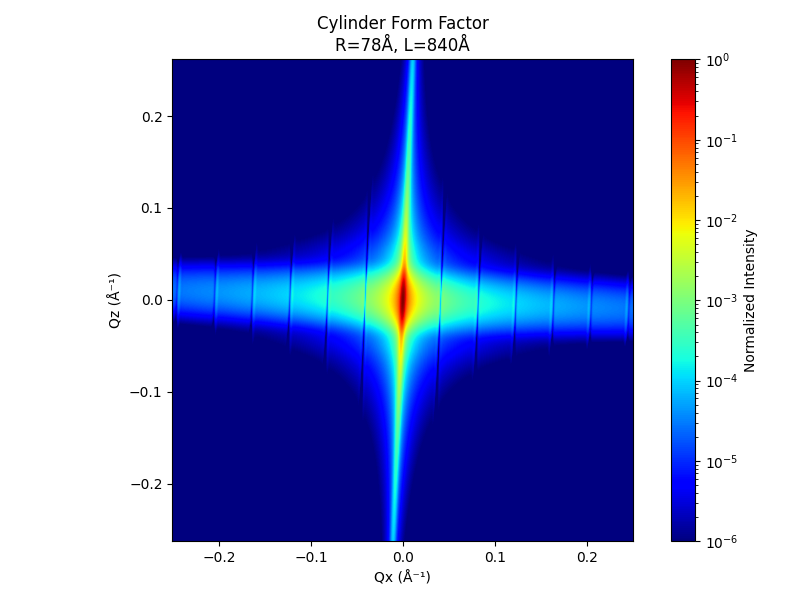


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=276.38_z=20.35_Img4_nematic_determination.png

Fitting results:
x0: 85.88793187265298
S: 0.9325738895492884
R2: 0.9099940237881087

************************************************************************************************************************

 Processing file 6 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_5.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_5.png
Mai

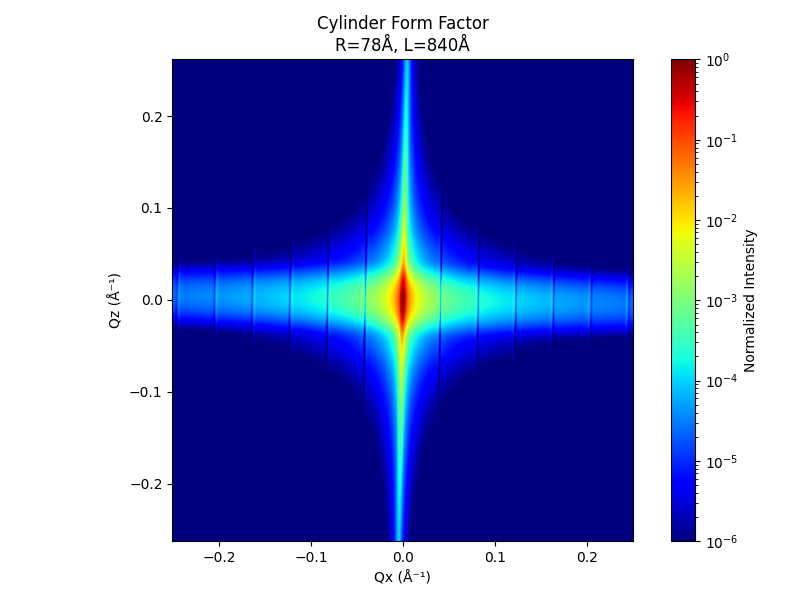


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=321.83_z=20.35_Img5_nematic_determination.png

Fitting results:
x0: 88.03333638098218
S: 0.9284824340867361
R2: 0.9102768286776799

************************************************************************************************************************

 Processing file 7 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_6.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_6.png
Mai

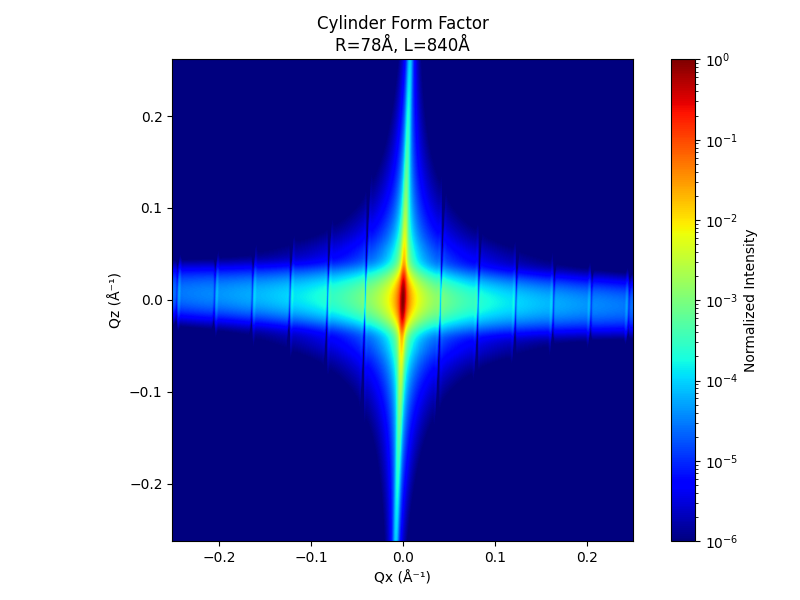


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=367.27_z=20.35_Img6_nematic_determination.png

Fitting results:
x0: 89.29750868991823
S: 0.9242742032719153
R2: 0.9089846172210797

************************************************************************************************************************

 Processing file 8 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_7.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_7.png
Mai

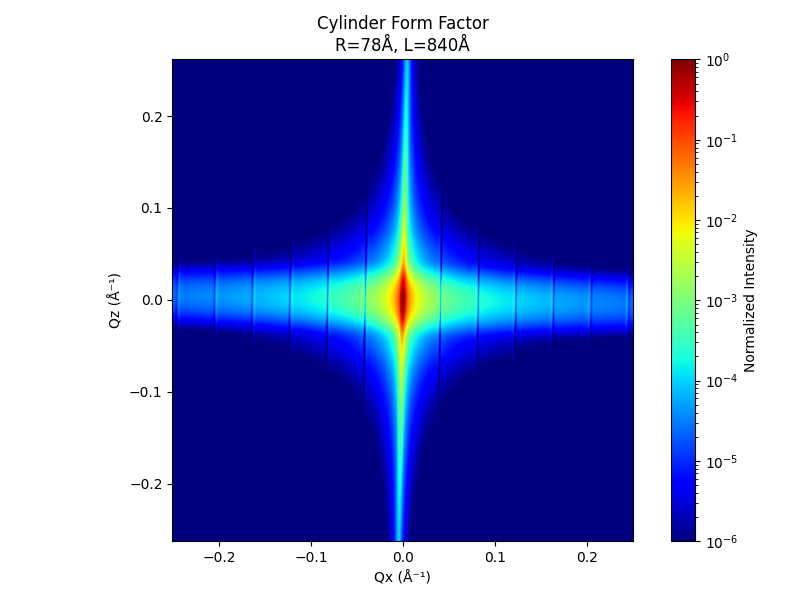


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=412.72_z=20.35_Img7_nematic_determination.png

Fitting results:
x0: 90.2508436528974
S: 0.9248053553959222
R2: 0.9102657257337952

************************************************************************************************************************

 Processing file 9 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_8.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_8.png
Main

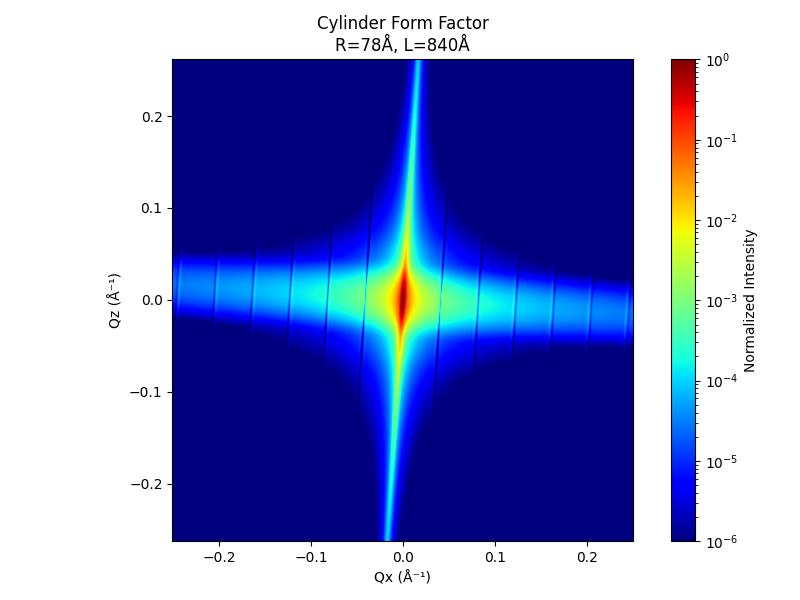


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=458.16_z=20.35_Img8_nematic_determination.png

Fitting results:
x0: 88.30897110151909
S: 0.8860333481264696
R2: 0.8177612849789229

************************************************************************************************************************

 Processing file 10 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_9.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_9.png
Ma

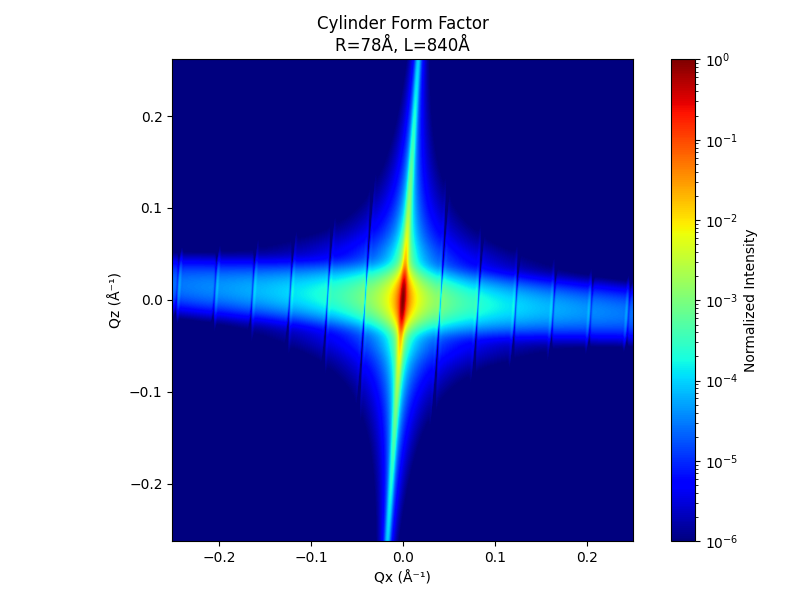


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=503.61_z=20.35_Img9_nematic_determination.png

Fitting results:
x0: 88.34189124978474
S: 0.8957512376272507
R2: 0.8424597315047664

************************************************************************************************************************

 Processing file 11 / 11: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/ag01_09_al4b_2_File_4288_Img_10.edf

************************************************************************************************************************
SAXS image saved: /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1//saxs_images/ag01_09_al4b_2_Img_10.png


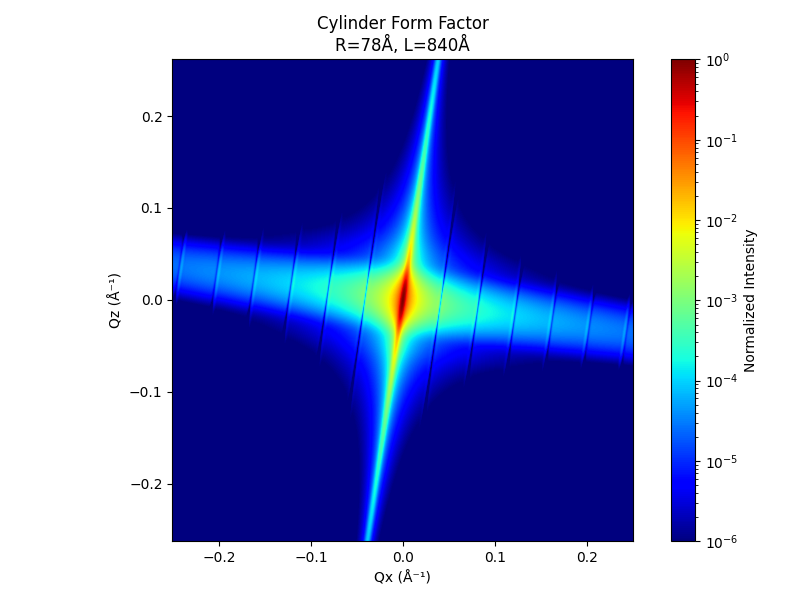


Fitting azimuthal profile to extract nematic order parameter...
 NematicOrderCalculator initialized with CylinderFormFactor
  Form factor profiles will be extracted on-the-fly for each q
Fit image saved in /home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/edf_files_1/azimuthal_profiles/ag01_09_al4b_2_B=0_x=549.05_z=20.35_Img10_nematic_determination.png

Fitting results:
x0: 79.73817172266286
S: 0.8360389355371552
R2: 0.9243297149308195


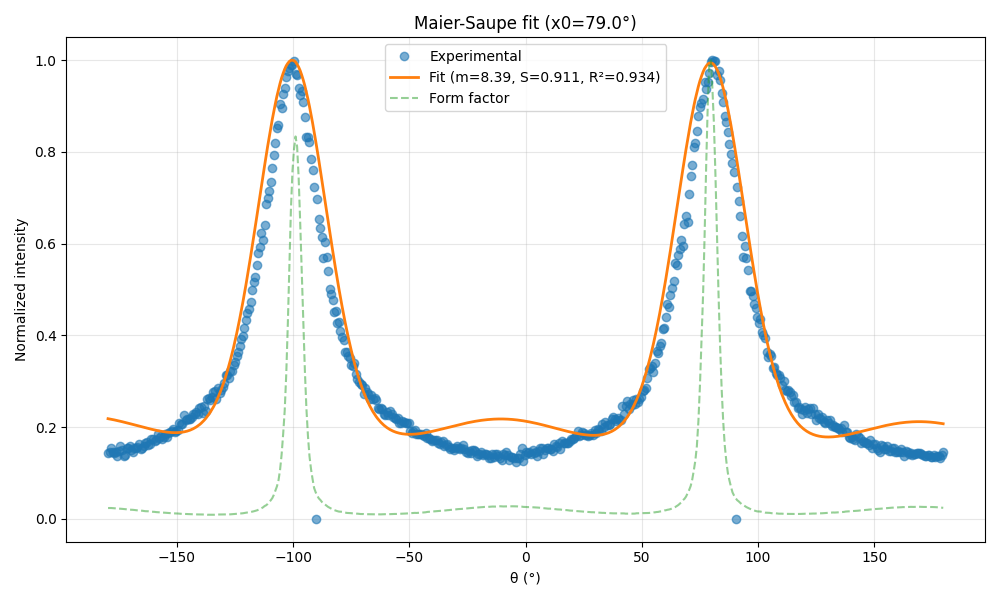

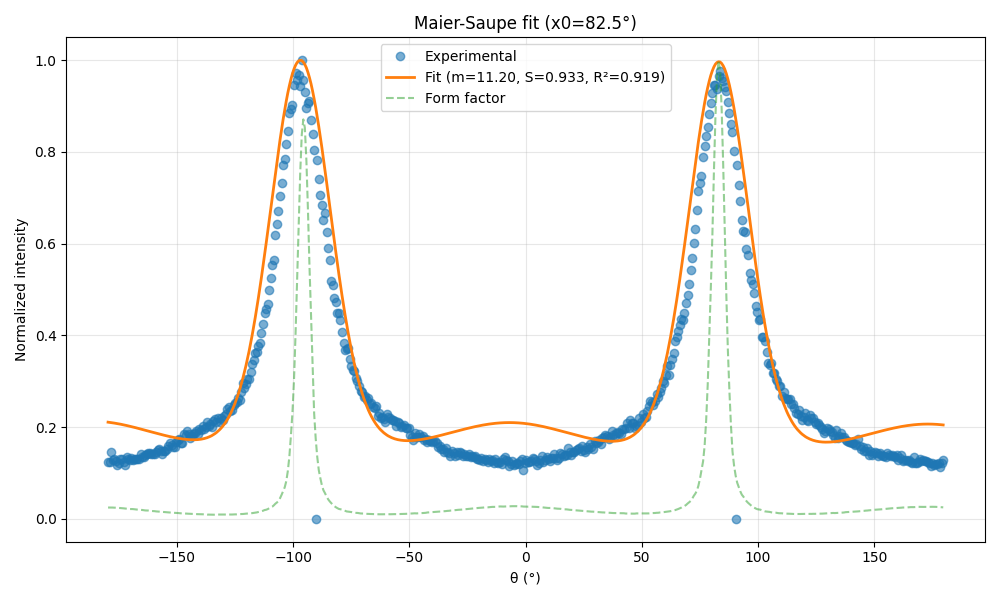

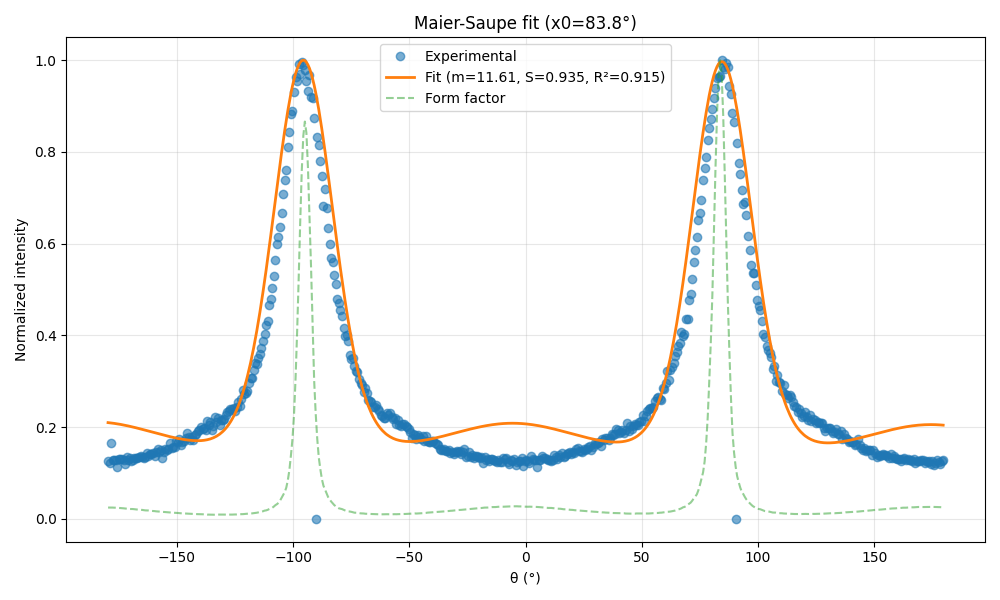

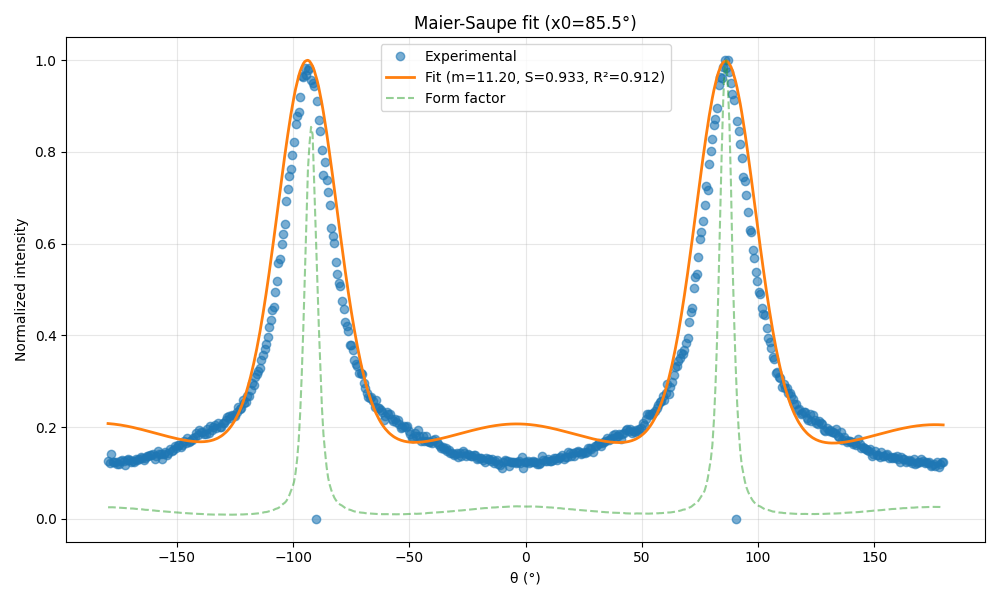

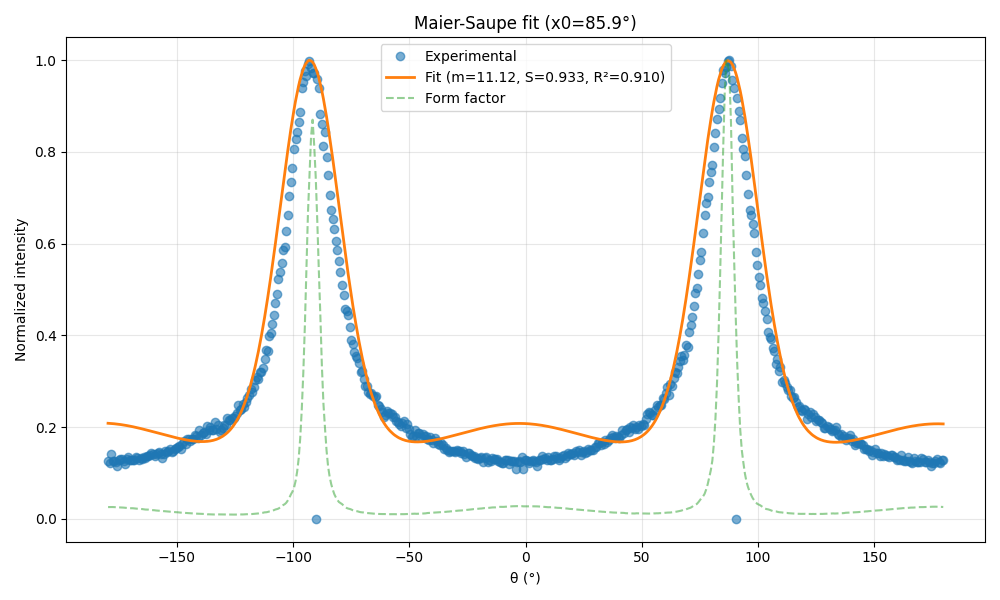

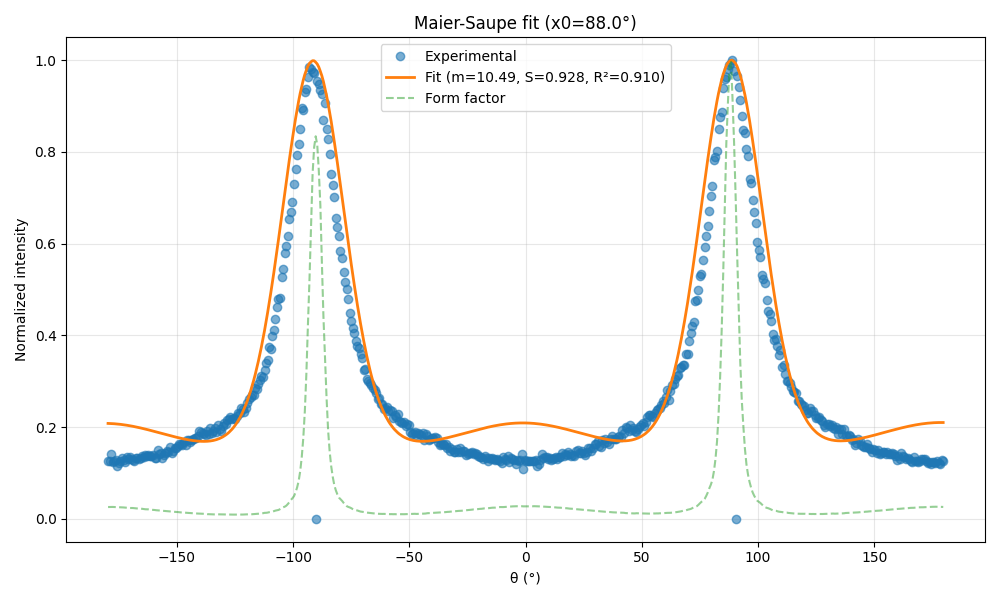

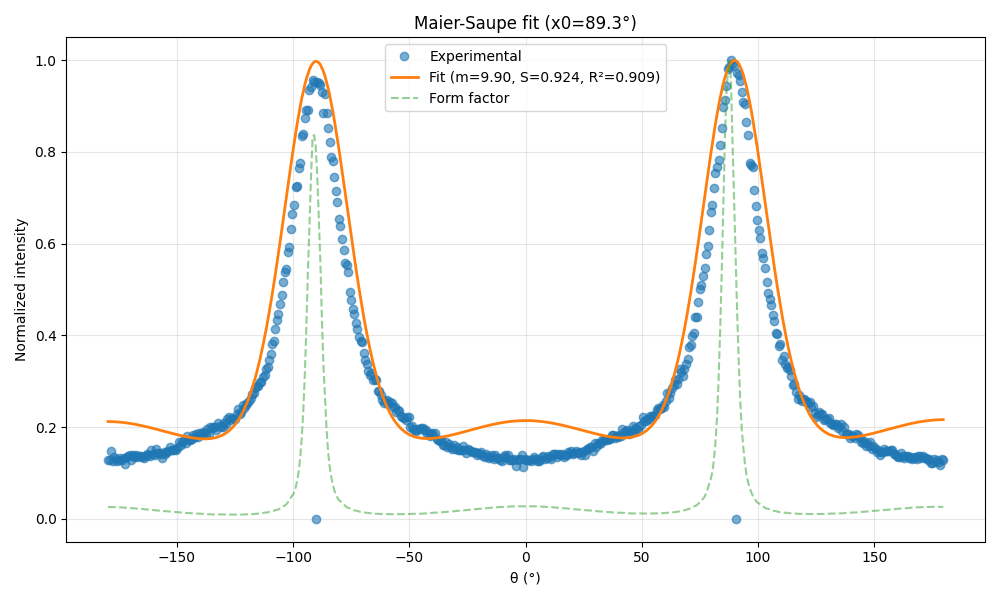

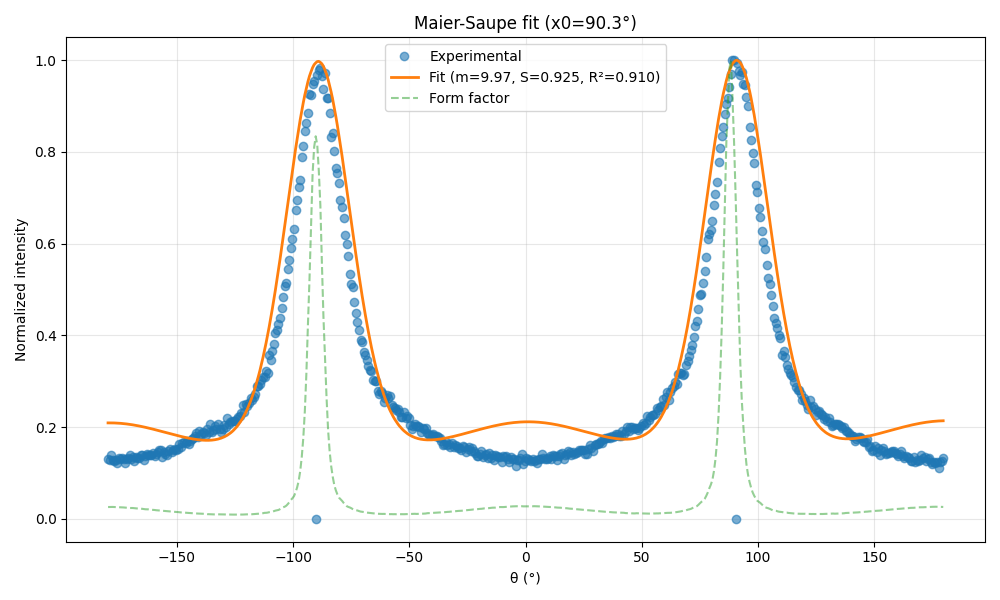

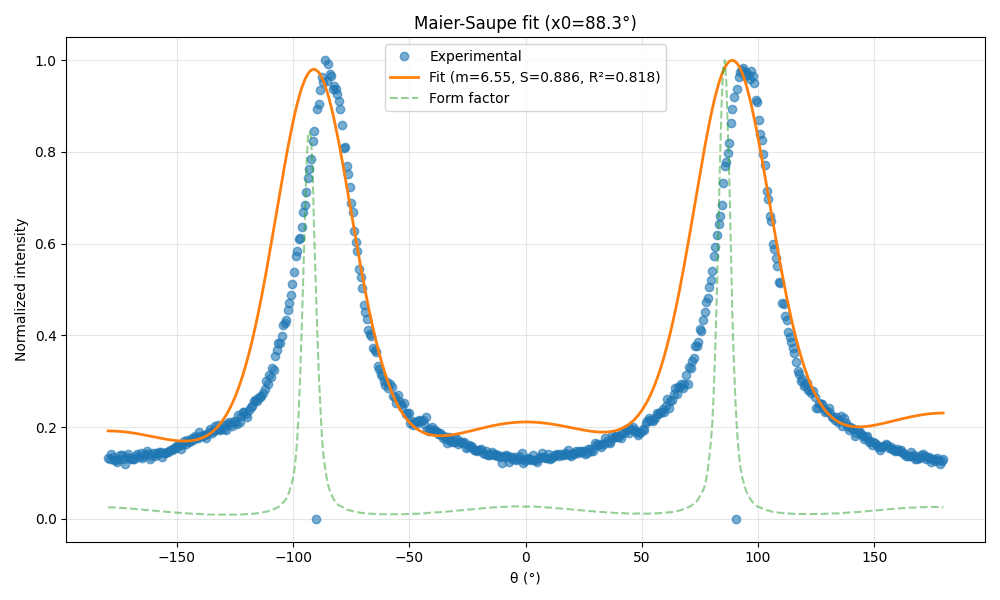

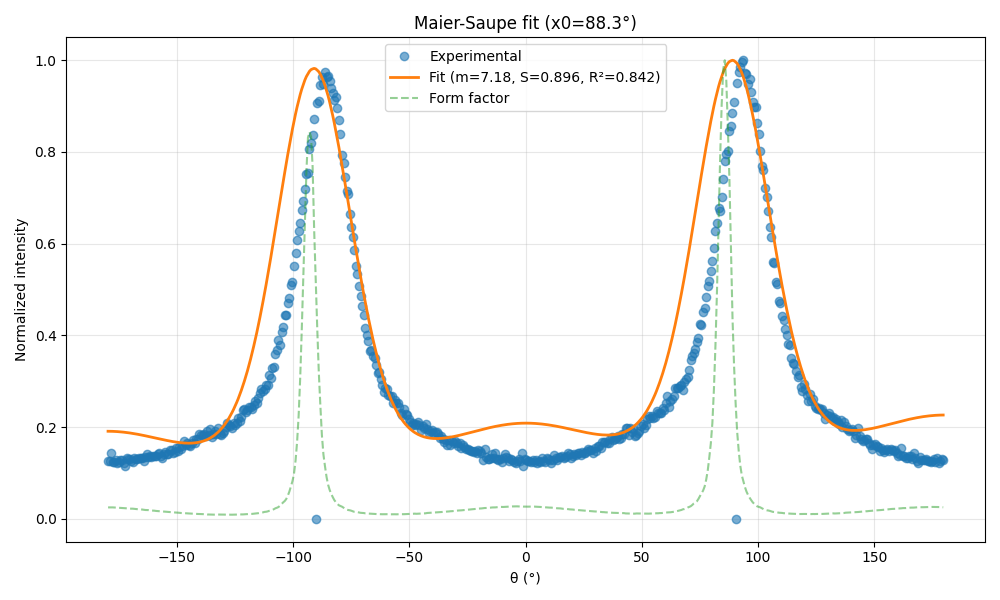

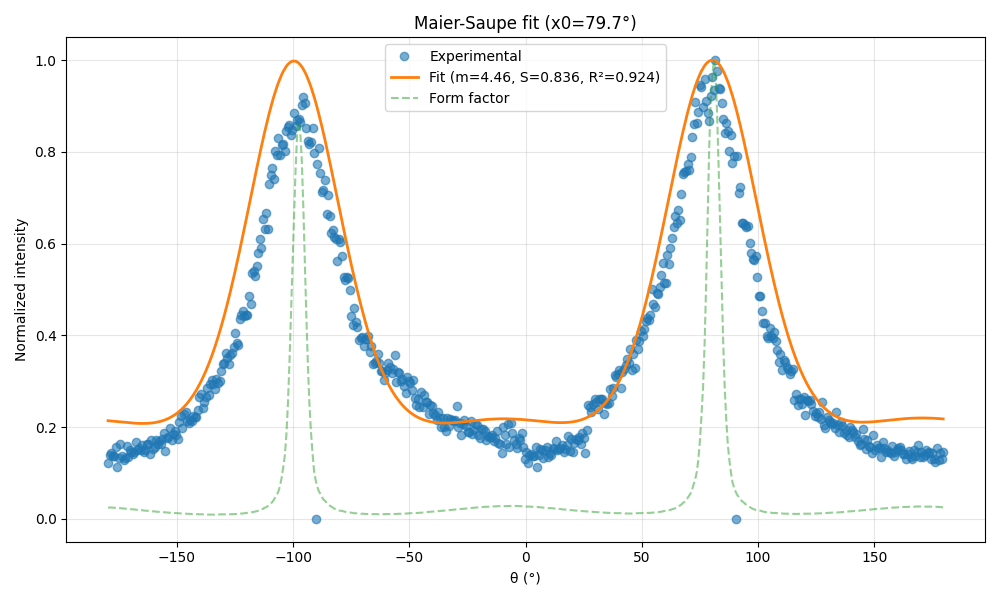

In [24]:
S_array = np.zeros(number_of_images)
x_array = np.zeros(number_of_images)
x0_array = np.zeros(number_of_images)
for i,file in enumerate(filelist):
    print('\n' + '*'*120)
    print(f'\n Processing file {i+1} / {number_of_images}: {file}')
    print('\n' + '*'*120)
    proc=SAXSProcessor(file, instrument='LGC',mask=mask) # instrument is set to 'LGC' as we are dealing with edf files now.
    proc.plot2d_vsq(q_range=(0,0.15), output_dir=edfpath)
    S,results = compute_nematic_parameter(processor=proc,plot=True, apply_mirror = False)
    S_array[i] = S
    x_array[i] = proc.x
    x0_array[i] = results['x0']

    

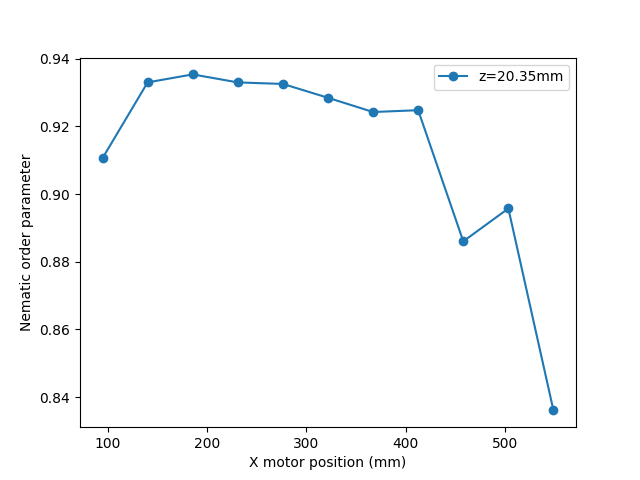

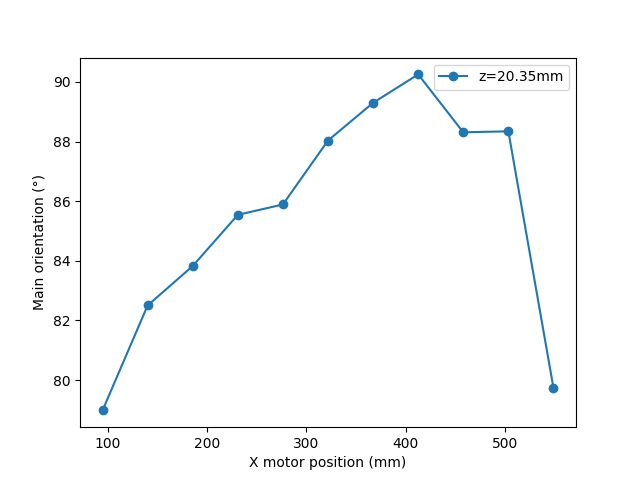

In [ ]:
plt.figure()
plt.plot(x_array,S_array, marker ='o', label=f'z={proc.z}mm')
plt.xlabel('X motor position (mm)')
plt.ylabel('Nematic order parameter')
plt.legend()

plt.figure()
plt.plot(x_array,x0_array, marker ='o', label=f'z={proc.z}mm')
plt.xlabel('X motor position (mm)')
plt.ylabel('Main orientation (°)')
plt.legend()

## Essai sur un assemblage complet

On a ici 2 fichiers h5, chacun correspondant à une ligne de scan µSAXS.
On va suivre la même procédure que pour un fichier unique:
- extraction des images saxs et conversion en edf
- utilisation de saxsprocessor pour extraire l'orientation principale (par exemple)

Pour le traitement d'un assemblage, il faut connaitre au préalable à quelle valeur de q on veut travailler pour extraire le profile azimuthal. Pour se faire, on va d'abord travailler sur un fichier individuel et extraire un profil radial moyen. Ce n'est pas montré ici car on a traité ci dessus le cas d'un fichier individuel.

Voici les arguments de la fonction utilisée:
    
    h5path: string
        Path to directory where data is stored
    
    mask:
        Path to mask file
    
    qvalue: float
        q value of interest at which azimuthal profile is extracted
    
    threshold: float
        relative value to defin the q range for azimuthal profile extraction
    
    radius: float
        Cylinder radius for form factor caclulation
    
    L: float
        Cylinder length for form factor calculation
    
    radius_pd, L_pd: float
        Polydispersity ratio for radius and length
    
    plot : bool
        Plot form factor and fitting results
    
    apply_mirror: bool
        Apply mirror symmetry to incomplete exp azimuthal profile


### Step 7/7
**Generating final nematic order map**

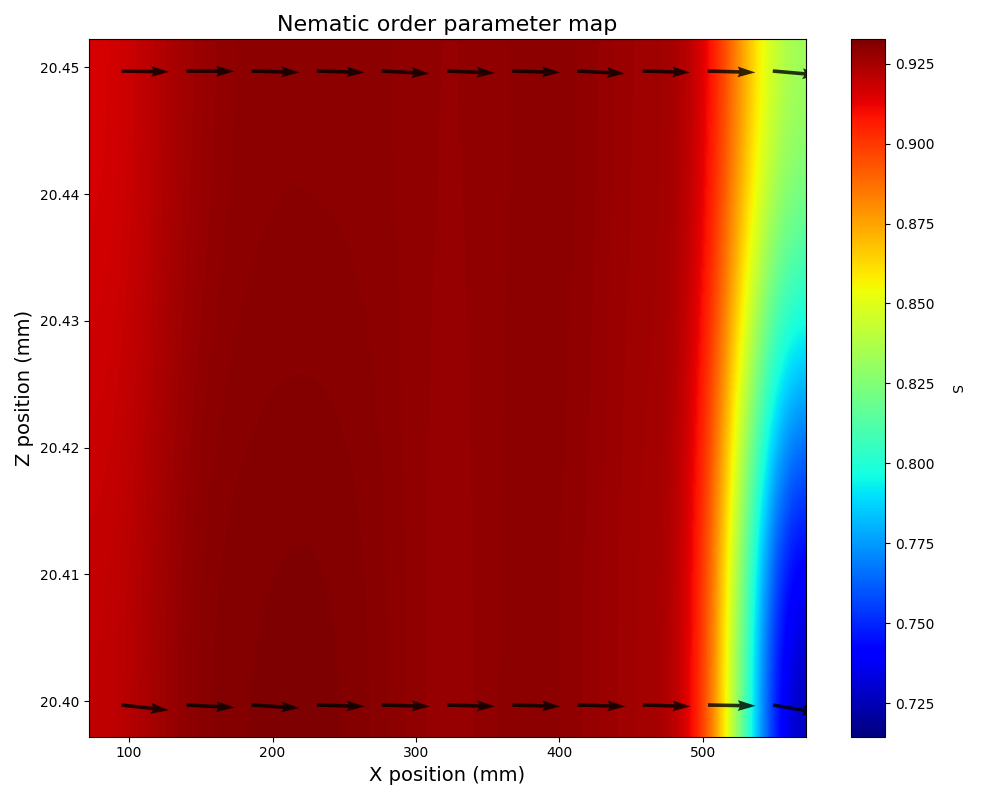

In [ ]:
from utilities import *
#h5path='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/'
h5path='/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/short_test/'
mask = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/mask.edf'

x_2d, z_2d, orientation_2d, S_2d, R2_2d = compute_nematic_order_assembly_SWING(h5path=h5path,mask=mask,qvalue=0.034, threshold=0.05,plot=False, apply_mirror=False, verbose=True)

#### **Réédition du plot sur assemblage complet**

On s'appuie ici sur des résultats obtenus précédemment et stockés dans un fichier csv produit par la fonction compute_nematic_order_assembly_SWING.
On applique un filtre sur le critère R2, afin de ne sélectionner que les points pertinents.

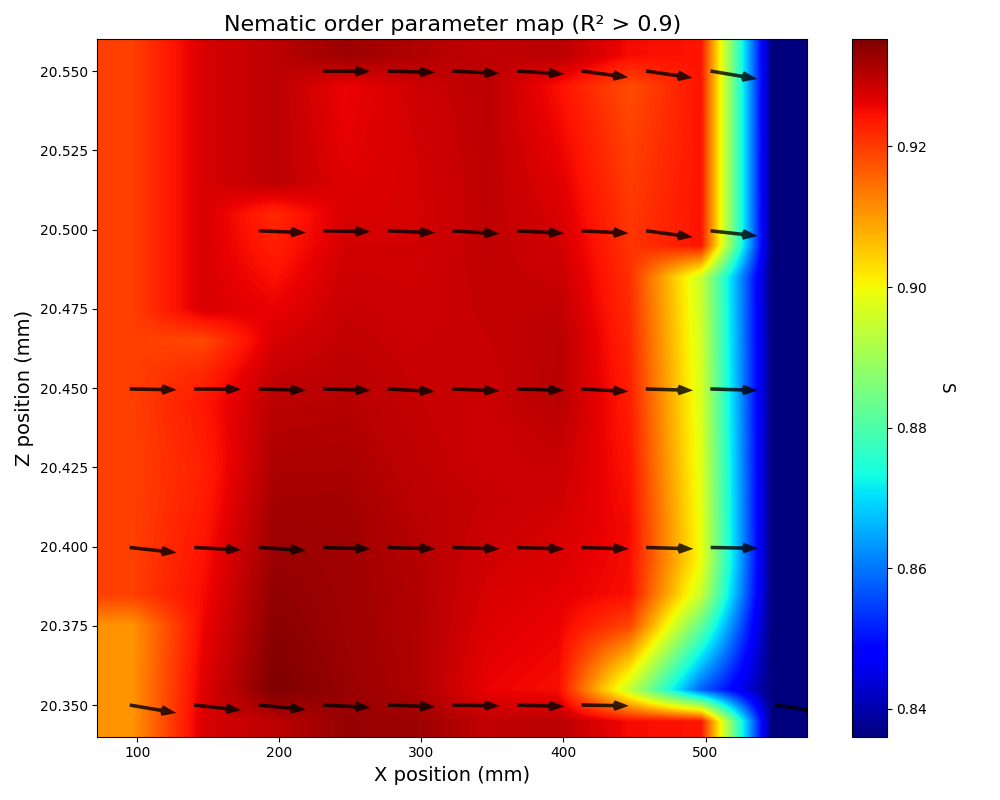

In [2]:
csvpath = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/nematic_processing_results/nematic_order_results.csv'
plot_from_csv(csvpath, R2_threshold=0.9)

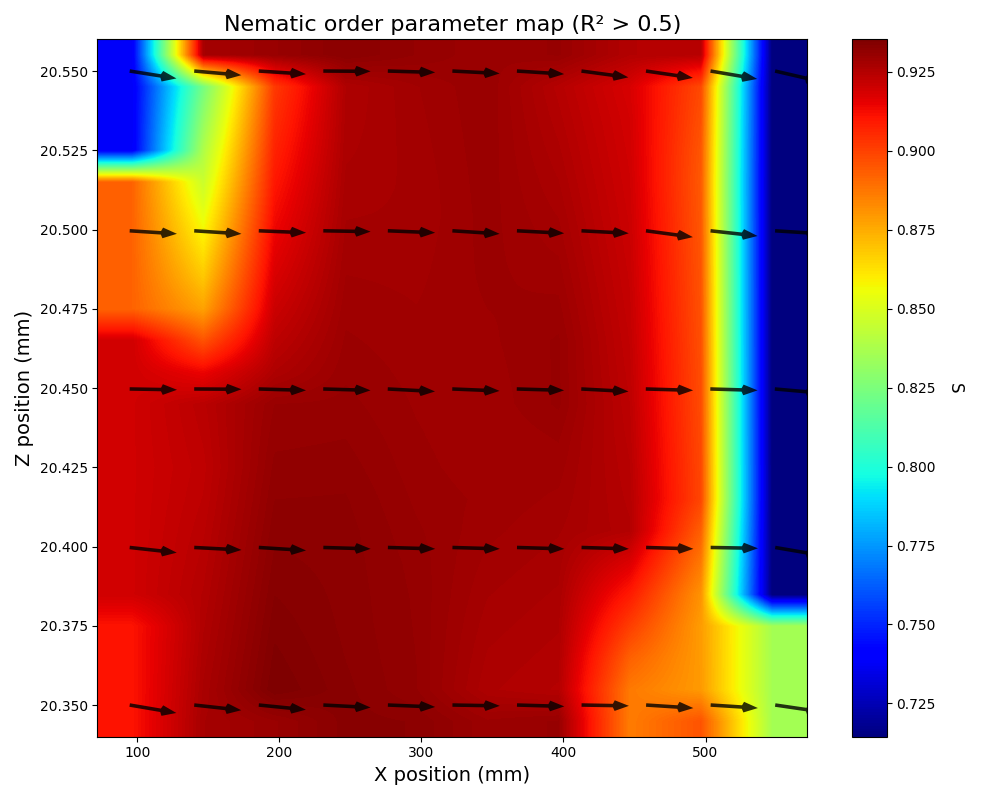

In [3]:
csvpath = '/home-local/ratel-ra/Documents/Python_code/SAXS_Processor/test_data/SWING/nematic_processing_results/nematic_order_results.csv'
plot_from_csv(csvpath, R2_threshold=0.5)